Сохранение в semantic3d_ready.npy ...

Первые 5 строк датасета:
[[-0.57024994  0.58578663  0.46104843  0.29019608  0.34509804  0.44705882
   0.01940701  7.        ]
 [-0.12870588 -0.20572724 -0.14128298  0.08627451  0.09019608  0.09803922
   0.13180593  1.        ]
 [-0.12728612 -0.2053723  -0.14128298  0.0745098   0.07058824  0.09019608
   0.1393531   1.        ]
 [-0.12693119 -0.2053723  -0.14163792  0.07058824  0.06666667  0.08627451
   0.13369272  1.        ]
 [-0.12551143 -0.20572724 -0.14305768  0.08627451  0.09019608  0.10588235
   0.12533693  1.        ]]


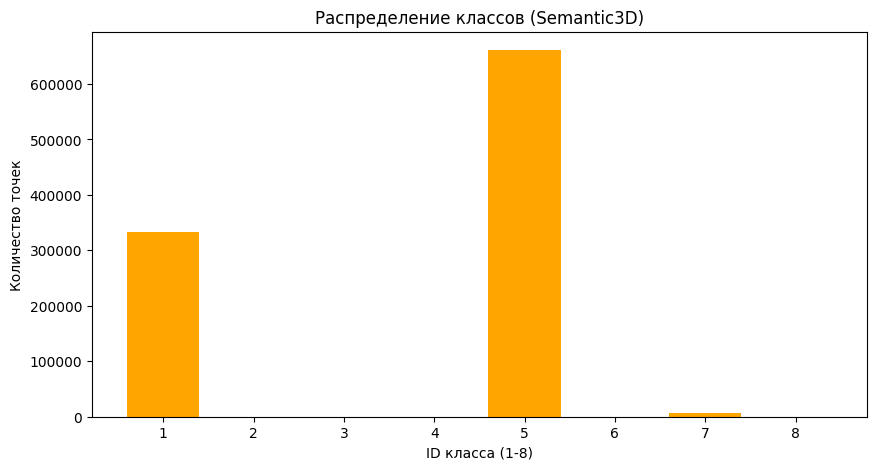

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def process_semantic3d(points_file, labels_file, output_name, limit_points=1000000):


    points = np.loadtxt(points_file, max_rows=limit_points)
    
    labels = np.loadtxt(labels_file, max_rows=limit_points).reshape(-1, 1)

    xyz = points[:, 0:3]
    intensity = points[:, 3].reshape(-1, 1)
    rgb = points[:, 4:7]

    xyz_offset = xyz - np.mean(xyz, axis=0)
    xyz_norm = xyz_offset / np.max(np.abs(xyz_offset))
    
    rgb_norm = rgb / 255.0
    
    intensity_norm = (intensity - intensity.min()) / (intensity.max() - intensity.min() + 1e-6)

    dataset = np.hstack((xyz_norm, rgb_norm, intensity_norm, labels))

    print(f"Сохранение в {output_name}.npy ...")
    np.save(f"{output_name}.npy", dataset)
    
    np.savetxt(f"{output_name}_preview.txt", dataset[:5], fmt='%.5f', 
               header="X Y Z R G B Intensity Label")
    
    return dataset

if __name__ == "__main__":

    try:
        data = process_semantic3d("birdfountain_station1_xyz_intensity_rgb.txt",
                                  "birdfountain1.labels", 
                                  "semantic3d_ready")
        
        print("\nПервые 5 строк датасета:")
        print(data[:5])
        
        # Визуализация распределения меток
        plt.figure(figsize=(10,5))
        plt.hist(data[:, -1], bins=np.arange(1, 10)-0.5, rwidth=0.8, color='orange')
        plt.title("Распределение классов (Semantic3D)")
        plt.xlabel("ID класса (1-8)")
        plt.ylabel("Количество точек")
        plt.xticks(range(1, 9))
        plt.show()

    except FileNotFoundError:
        print("Ошибка")